In [3]:
import os
import random
id = os.listdir("/path/to/digiface")
train_ids = random.sample(id, len(id)*90//100)
val_ids = list(set(id) - set(train_ids))
with open("full_index.txt", "w") as f:
    for tid in train_ids:
        for faces in os.listdir(os.path.join("/path/to/digiface", tid))[:2]:
            f.write(f"{tid}/{faces} train\n")
    for vid in val_ids:
        for faces in os.listdir(os.path.join("/path/to/digiface", vid))[:2]:
            f.write(f"{vid}/{faces} val\n")

In [5]:
len(train_ids) 

89999

In [ ]:
import cv2
from insightface.app import FaceAnalysis

import os
import random
id = os.listdir("/path/to/digiface")
train_ids = random.sample(id, len(id)*80//100)
val_ids = list(set(id) - set(train_ids)) 
all_files = []
for i in train_ids:
    files = os.listdir(os.path.join("/path/to/digiface", i))[:2]
    files = [i+"/"+f for f in files]
    all_files.extend(files)

for i in val_ids:
    files = os.listdir(os.path.join("/path/to/digiface", i))[:2]
    files = [i+"/"+f for f in files]
    all_files.extend(files)

In [ ]:
import numpy as np
app = FaceAnalysis(name='antelopev2', root='./', providers=['CPUExecutionProvider'])


app.prepare(ctx_id=0, det_size=(160, 160))
os.makedirs("/path/to/digiface/insight_embeddings", exist_ok=True)
def get_embedding(image_path):
    image = cv2.imread("/path/to/digiface/"+image_path)
    if image is None:
        print("Failed to read image", image_path)
        return None
    image = cv2.resize(image, (160,160))
    faces = app.get(image)
    if len(faces) == 0:
        print("No face found in", image_path)
        return None
    face = faces[0]
    embedding = face.embedding
    np.save("/path/to/digiface/insight_embeddings/"+image_path.replace(".jpg", ".npy").replace("/","_"), embedding)
    

# use a pool of 64 cpus with tqdm
from multiprocessing import Pool
import tqdm

with Pool(130) as p:
    list(tqdm.tqdm(p.imap(get_embedding, all_files), total=len(all_files)))



In [ ]:
files = os.listdir("/path/to/digiface/insight_embeddings")
ids = set([f.split("_")[0] for f in files]) 
len(ids)

99898

In [4]:
train_ids = random.sample(list(ids), len(ids)*90//100)
val_ids = list(set(ids) - set(train_ids))
train_ids = set(train_ids)
train_files = []
val_files = []
for f in files:
    id = f.split("_")[0]
    if id in train_ids:
        train_files.append(f)
    else:
        val_files.append(f)

In [5]:
with open("index.txt", "w") as f:
    for i in train_files:
        f.write(f"{i.replace('_', '/').replace('.npy', '.jpg')} train\n")
    for i in val_files:
        f.write(f"{i.replace('_', '/').replace('.npy', '.jpg')} val\n")

In [6]:
import os
filelist = os.listdir("training-tpdne")

In [7]:
with open("tpdne_index.txt", "w") as f:
    for file in filelist:
        f.write(f"{file} val\n")

In [8]:
import pickle
with open("./log/insight_student_embeddings_val_epoch_final.pkl", "rb") as f:
    id_embs = pickle.load(f)

KeyboardInterrupt: 

In [ ]:
id_embs.keys()

dict_keys(['filenames', 'student_embeddings', 'teacher_embeddings', 'templates'])

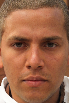

In [ ]:
from PIL import Image
Image.open(id_embs["filenames"][0][0])

In [ ]:
import numpy as np
from insightface.app import FaceAnalysis
app = FaceAnalysis(name='antelopev2', root='./', providers=['CPUExecutionProvider'])

import os
app.prepare(ctx_id=0, det_size=(160, 160))
def get_embedding(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print("Failed to read image", image_path)
        return None
    image = cv2.resize(image, (160,160))
    faces = app.get(image)
    if len(faces) == 0:
        print("No face found in", image_path)
        return None
    face = faces[0]
    embedding = face.embedding
    return embedding

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./models/antelopev2/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./models/antelopev2/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./models/antelopev2/arcface.onnx recognition ['None', 3, 112, 112] 127.5 127.5
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./models/antelopev2/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./models/antelopev2/scrfd_10g_bnkps.onnx detection [1, 3, '?', '?'] 127.5 128.0
set det-size: (160, 160)


In [ ]:
import cv2
gt = get_embedding(id_embs["filenames"][0][0])

In [ ]:
gt = gt / np.linalg.norm(gt)
pred = id_embs["student_embeddings"][0][0]
pred = pred / np.linalg.norm(pred) 
np.dot(gt, pred) 

/tmp/ipykernel_547216/3162324013.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.dot(gt, pred)


np.float32(0.732047)

In [2]:
import pickle
with open("../../attacks/partialface/log/insight_student_embeddings_val_epoch4.pkl", "rb") as f:
    id_embs = pickle.load(f)

In [ ]:
id_embs.keys()

dict_keys(['filenames', 'student_embeddings', 'teacher_embeddings', 'templates'])

In [17]:
import os
all_ids = list(set(i.split("_")[0] for i in os.listdir("/path/to/casia-webface/insight_embeddings")))

In [26]:
all_files = {}
for i in os.listdir("/path/to/casia-webface/insight_embeddings"):
    id = i.split("_")[0]
    if id not in all_files:
        all_files[id] = []
    all_files[id].append(i.split("_")[1])

In [27]:
filenames = sum(id_embs["filenames"], [])

In [28]:
val_ids = set([i.split("/")[-2] for i in filenames])

In [29]:
with open("index.txt", "w") as f:
    for id in all_ids:
        if id in val_ids:
            for file in all_files[id]:
                f.write(f"{id}/{file.replace('.npy', '.jpg')} val\n")
        else:
            for file in all_files[id]:
                f.write(f"{id}/{file.replace('.npy', '.jpg')} train\n")

In [1]:
import pickle
with open("../../evaluation/results/holdout_original_embeddings.pkl", "rb") as f:
    id_embs = pickle.load(f)

In [ ]:
id_embs["images"][0][:,:,::-1]

array([[[172, 171, 187],
        [172, 171, 187],
        [173, 172, 190],
        ...,
        [ 44,  11,   4],
        [ 43,   5,   4],
        [ 43,   5,   4]],

       [[171, 170, 186],
        [172, 171, 187],
        [173, 172, 190],
        ...,
        [ 44,  11,   4],
        [ 43,   5,   4],
        [ 43,   5,   4]],

       [[171, 170, 186],
        [172, 171, 187],
        [173, 172, 190],
        ...,
        [ 45,  12,   5],
        [ 43,   5,   4],
        [ 43,   5,   4]],

       ...,

       [[ 20,  14,  42],
        [ 20,  14,  42],
        [ 20,  14,  42],
        ...,
        [ 13,   4,  23],
        [ 16,   4,  24],
        [ 16,   4,  24]],

       [[ 20,  14,  42],
        [ 21,  15,  43],
        [ 21,  15,  43],
        ...,
        [ 16,   7,  26],
        [ 16,   4,  24],
        [ 16,   4,  24]],

       [[ 20,  14,  42],
        [ 21,  15,  43],
        [ 21,  15,  43],
        ...,
        [ 16,   7,  26],
        [ 16,   4,  24],
        [ 16,   4,  24]]